# The Galaxy Stellar Mass Function
## A practical introduction using the DESI BGS Legacy Survey DR10 sample

**Data:** Comparat et al. (2025), A&A 697, A173  
**arXiv:** [2503.19796](https://arxiv.org/abs/2503.19796)  
**DOI:** [10.1051/0004-6361/202554208](https://doi.org/10.1051/0004-6361/202554208)

---

## Learning objectives

After this tutorial you will be able to:
1. Load and explore a real galaxy survey catalog (FITS format).
2. Understand the concept of the **Stellar Mass Function (SMF)**.
3. Apply three independent non-parametric estimators: $1/V_{\rm max}$, SWML, and $C^-$.
4. Estimate Poisson uncertainties on the SMF.
5. Compare your measurement to the Schechter function literature reference.

---

## 1. Theoretical background

### 1.1 What is the Stellar Mass Function?

The **Stellar Mass Function** $\Phi(M_*)$ describes the number density of galaxies per unit comoving volume per unit logarithmic stellar mass interval:

$$\Phi(\log_{10} M_*)\, d\log_{10} M_* = \text{number of galaxies per Mpc}^3 \text{ with stellar mass in } [\log_{10} M_*, \log_{10} M_* + d\log_{10} M_*]$$

Units: $[\Phi] = \mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}$.

Measuring the SMF is a fundamental test of galaxy formation models: the abundance and mass distribution of galaxies encodes how efficiently baryons convert into stars inside dark matter halos.

### 1.2 The Schechter function

Schechter (1976) proposed the following analytical form to describe the galaxy luminosity function, which also describes the SMF very well:

$$\Phi(M)\,dM = \ln(10)\,e^{-x}\left[\Phi_1^* x^{\alpha_1+1} + \Phi_2^* x^{\alpha_2+1}\right]\,d\log_{10} M$$

where $x = M_*/M^* = 10^{\log_{10}M - \log_{10}M^*}$, $M^*$ is a characteristic mass above which the function cuts off exponentially, $\alpha$ is the faint-end slope, and $\Phi^*$ is the normalisation (units: $\mathrm{Mpc}^{-3}$).

At low masses ($M \ll M^*$), $\Phi \propto M^\alpha$ (a power law). At high masses ($M \gg M^*$), $\Phi \propto e^{-M/M^*}$ (exponential suppression).

The **double Schechter** function (two components with same $M^*$) is needed at low redshift to account for the upturn from blue, star-forming dwarf galaxies at low masses:

$$\Phi(M) = \ln(10)\,e^{-x}\left[\Phi_1^* x^{\alpha_1+1} + \Phi_2^* x^{\alpha_2+1}\right]$$

Reference: Schechter (1976), ApJ 203, 297.

### 1.3 The three estimators

We will use three independent non-parametric estimators:

| Estimator | Reference | Key idea |
|-----------|-----------|----------|
| $1/V_{\rm max}$ | Schmidt (1968), ApJ 151, 393 | Each galaxy contributes $1/V_{\rm max}$ to its bin |
| SWML | Efstathiou, Ellis & Peterson (1988), MNRAS 232, 431 | Maximise a step-wise likelihood; density-independent |
| $C^-$ | Lynden-Bell (1971), MNRAS 155, 95 | Non-parametric cumulative estimator; density-independent |

A pedagogical review of all three methods is given in Johnston (2011), [arXiv:1106.2039](https://arxiv.org/abs/1106.2039).

### 1.4 The $1/V_{\rm max}$ estimator in detail

For each galaxy $i$ with stellar mass $\log_{10} M_{*,i}$ and redshift $z_i$, we define the **maximum comoving volume** $V_{\rm max,i}$ as the largest volume in which the galaxy could have been observed by the survey:

$$V_{\rm max,i} = \frac{\Omega_{\rm survey}}{4\pi}\left[V_c(\min(z_{\rm max}, z_{\rm max,i})) - V_c(z_{\rm min})\right]$$

where $V_c(z)$ is the comoving volume, $\Omega_{\rm survey}$ is the survey solid angle, and $z_{\rm max,i}$ is the maximum redshift at which galaxy $i$ would still be selected (for a mass-limited sample, $z_{\rm max,i} = z_{\rm max}$ for all galaxies above the completeness limit).

The SMF estimator is then:

$$\hat{\Phi}_j = \frac{1}{\Delta\log_{10} M_j}\sum_{i \in {\rm bin}\ j} \frac{w_i}{V_{\rm max,i}}$$

with Poisson uncertainty:

$$\sigma_j = \frac{1}{\Delta\log_{10} M_j}\sqrt{\sum_{i \in {\rm bin}\ j} \left(\frac{w_i}{V_{\rm max,i}}\right)^2}$$

Reference: Schmidt (1968), ApJ 151, 393; Condon (1989), ApJ 338, 13.

---

## 2. Setup and imports

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
import healpy as hp

# sum_stat estimators
from sum_stat.catalogue import GalaxyCatalogue
from sum_stat.lf_smf.vmax import stellar_mass_function_vmax
from sum_stat.lf_smf.swml import stellar_mass_function_swml
from sum_stat.lf_smf.cminus import cumulative_stellar_mass_function_cminus

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.labelsize': 14,
    'legend.fontsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Imports OK')

Imports OK


---

## 3. Loading the data

### 3.1 The BGS LS10 volume-limited sample

We use a **volume-limited** galaxy sample from the Legacy Survey Data Release 10 (LS10), constructed following the DESI Bright Galaxy Survey (BGS) selection (Hahn et al. 2023, ApJS 963, 168).

The sample properties are encoded in the filename:
- `ANY` — all galaxy types (blue + red)
- `10.0` — minimum $\log_{10}(M_*/M_\odot) > 10.0$
- `Mstar_12.0` — maximum $\log_{10}(M_*/M_\odot) < 12.0$
- `0.05_z_0.18` — redshift range $0.05 < z < 0.18$
- `N_2759238` — 2,759,238 galaxies

**Key FITS columns:**
| Column | Description |
|--------|-------------|
| `RA` | Right ascension [deg] |
| `DEC` | Declination [deg] |
| `EBV` | Galactic dust extinction $E(B-V)$ [mag] |
| `LPH_MASS_BEST` | $\log_{10}(M_*/M_\odot)$ from photometric SED fitting |
| `BEST_Z` | Best photometric redshift |

Stellar masses and photometric redshifts follow Zhou et al. (2021), ApJ 910, 121 and Ilbert et al. (2013), [A&A 556, A55](https://doi.org/10.1051/0004-6361/201321100).

The corresponding **random catalog** (`_RAND.fits`) contains 13,795,884 random points uniformly distributed over the survey footprint, sampling the same redshift distribution as the data. The ratio $N_{\rm rand}/N_{\rm data} \approx 5$ ensures the random shot noise is subdominant.

In [2]:
# File paths
DATA_FILE = ('/home/comparat/data/legacysurvey/dr10/sweep/BGS_VLIM_Mstar/'
             'LS10_VLIM_ANY_10.0_Mstar_12.0_0.05_z_0.18_N_2759238_DATA.fits')
RAND_FILE = ('/home/comparat/data/legacysurvey/dr10/sweep/BGS_VLIM_Mstar/'
             'LS10_VLIM_ANY_10.0_Mstar_12.0_0.05_z_0.18_N_2759238_RAND.fits')

# Load data
with fits.open(DATA_FILE) as hdul:
    data = hdul[1].data
    print(f'DATA: {len(data):,} galaxies')
    print('Columns:', data.names)

ra    = data['RA'].astype(np.float64)
dec   = data['DEC'].astype(np.float64)
z     = data['BEST_Z'].astype(np.float64)
mstar = data['LPH_MASS_BEST'].astype(np.float64)  # log10(M*/Msun)

print(f'Redshift range : {z.min():.3f} – {z.max():.3f}')
print(f'log10(M*) range: {mstar.min():.2f} – {mstar.max():.2f}')

DATA: 2,759,238 galaxies
Columns: ['RA', 'DEC', 'EBV', 'LPH_MASS_BEST', 'BEST_Z']


Redshift range : 0.050 – 0.180
log10(M*) range: 10.00 – 12.00


### 3.2 Computing the survey area

We estimate the survey solid angle $\Omega_{\rm survey}$ from the random catalog using **HEALPix** pixelization (Górski et al. 2005). We choose `nside=256` (pixel area $\approx 0.052\,{\rm deg}^2$), count the number of pixels containing at least one random point, and multiply by the pixel area.

This gives the effective footprint of the survey, automatically masking regions excluded by the survey (bright stars, bad seeing, etc.).

In [3]:
# Load randoms (only need RA, DEC for area estimate)
with fits.open(RAND_FILE) as hdul:
    rdata = hdul[1].data
    rand_ra  = rdata['RA'].astype(np.float64)
    rand_dec = rdata['DEC'].astype(np.float64)
    rand_z   = rdata['Z'].astype(np.float64)
    print(f'RAND: {len(rand_ra):,} random points')

# Compute survey area with HEALPix nside=256
NSIDE_AREA = 256
pix_ids = hp.ang2pix(NSIDE_AREA, rand_ra, rand_dec, lonlat=True)
n_occupied = len(np.unique(pix_ids))
pix_area_deg2 = hp.nside2pixarea(NSIDE_AREA, degrees=True)

area_deg2 = n_occupied * pix_area_deg2
area_sr   = area_deg2 * (np.pi / 180.0)**2

print(f'Survey area: {area_deg2:,.0f} deg²  ({area_sr:.2f} sr)')
print(f'(Comparat et al. 2025 report ~16 800 deg² for the full LS10 footprint)')

RAND: 13,795,884 random points


Survey area: 17,747 deg²  (5.41 sr)
(Comparat et al. 2025 report ~16 800 deg² for the full LS10 footprint)


### 3.3 Exploring the data

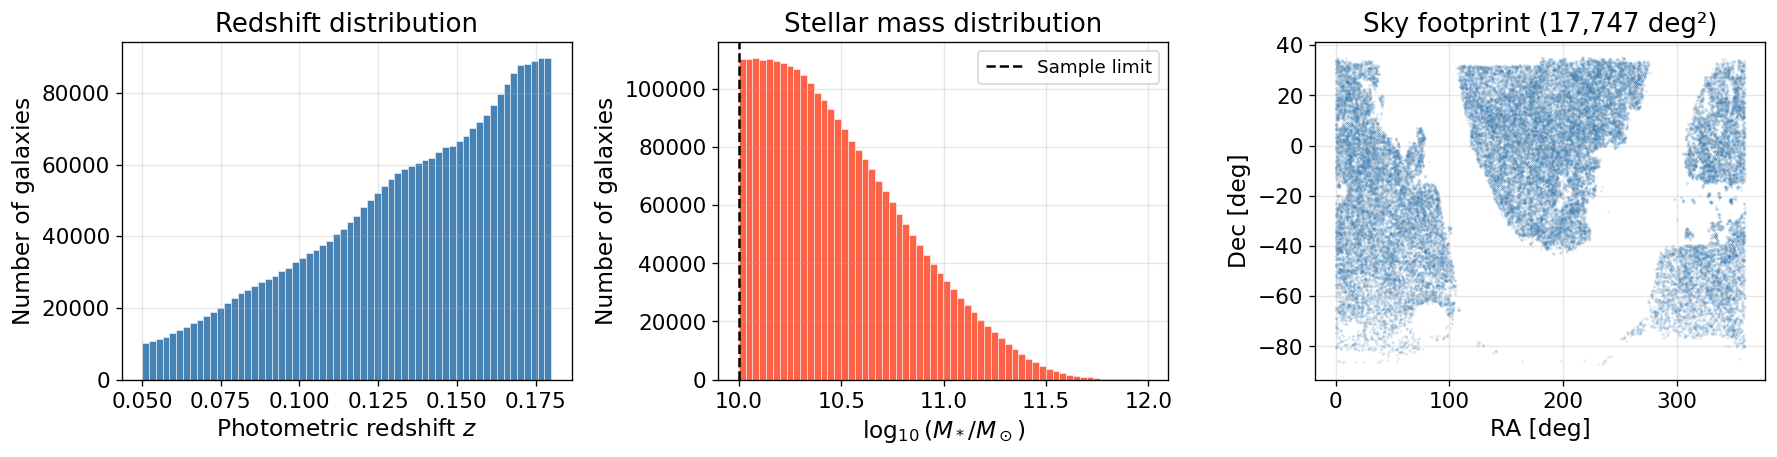

Figure saved.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Redshift distribution
ax = axes[0]
ax.hist(z, bins=60, color='steelblue', edgecolor='white', lw=0.3)
ax.set_xlabel('Photometric redshift $z$')
ax.set_ylabel('Number of galaxies')
ax.set_title('Redshift distribution')

# Stellar mass distribution
ax = axes[1]
ax.hist(mstar, bins=60, color='tomato', edgecolor='white', lw=0.3)
ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$')
ax.set_ylabel('Number of galaxies')
ax.set_title('Stellar mass distribution')
ax.axvline(10.0, color='k', ls='--', label='Sample limit')
ax.legend()

# Sky projection (RA–Dec footprint, subsample for speed)
ax = axes[2]
idx_plot = np.random.choice(len(ra), size=50_000, replace=False)
ax.scatter(ra[idx_plot], dec[idx_plot], s=0.1, alpha=0.3, color='steelblue', rasterized=True)
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title(f'Sky footprint ({area_deg2:,.0f} deg²)')

plt.tight_layout()
plt.savefig('smf_data_exploration.pdf', bbox_inches='tight')
plt.show()
print('Figure saved.')

---

## 4. Setting up the catalogue and cosmology

### 4.1 Cosmology

We use the **Planck 2018** flat $\Lambda$CDM cosmology adopted by Comparat et al. (2025):

| Parameter | Value |
|-----------|-------|
| $H_0$ | 67.66 km/s/Mpc |
| $\Omega_m$ | 0.26069 |
| $\Omega_\Lambda$ | 0.73931 |

The comoving volume element $dV_c/dz$ is computed by astropy, which handles the proper distance integration:

$$V_c(z) = \frac{4\pi}{3}\left[\frac{c}{H_0}\int_0^z \frac{dz'}{E(z')}\right]^3, \quad E(z) = \sqrt{\Omega_m(1+z)^3 + \Omega_\Lambda}$$

### 4.2 Survey limits

This is a **stellar mass-selected volume-limited** sample:
- Minimum redshift $z_{\rm min} = 0.05$ (avoids local large-scale structure effects)
- Maximum redshift $z_{\rm max} = 0.18$ (survey completeness limit)
- Stellar mass limit $\log_{10}(M_{*,\rm lim}/M_\odot) = 10.0$ (uniform above this)

Because the sample is mass-selected (not flux-limited), every galaxy with $\log_{10} M_* > 10.0$ is observed throughout the full redshift range. This means $V_{\rm max,i} = V_{\rm max}$ for all galaxies — a great simplification!

In [5]:
# Cosmology (Planck 2018, Comparat et al. 2025)
cosmo = FlatLambdaCDM(H0=67.66, Om0=0.26069)

# Survey limits
Z_MIN = 0.05
Z_MAX = 0.18
MSTAR_LIMIT = 10.0  # log10(M*/Msun) — uniform completeness above this

# Apply z cuts (sample is already cut, but enforce for safety)
mask = (z >= Z_MIN) & (z <= Z_MAX) & (mstar >= MSTAR_LIMIT)
ra_s    = ra[mask]
dec_s   = dec[mask]
z_s     = z[mask]
mstar_s = mstar[mask]
print(f'Galaxies after cuts: {mask.sum():,} (removed {(~mask).sum():,})')

# Maximum survey volume (same for all galaxies in mass-limited sample)
vc_max = cosmo.comoving_volume(Z_MAX).to('Mpc3').value
vc_min = cosmo.comoving_volume(Z_MIN).to('Mpc3').value
V_survey = (area_sr / (4.0 * np.pi)) * (vc_max - vc_min)
print(f'Survey comoving volume: {V_survey:.3e} Mpc³')
print(f'Mean galaxy number density: {mask.sum() / V_survey:.3e} Mpc⁻³')

Galaxies after cuts: 2,759,238 (removed 0)
Survey comoving volume: 7.982e+08 Mpc³
Mean galaxy number density: 3.457e-03 Mpc⁻³


In [6]:
# Build the GalaxyCatalogue object (sum_stat API)
# weight=1 for each galaxy (this is a complete, unweighted sample)
cat = GalaxyCatalogue(
    ra          = ra_s,
    dec         = dec_s,
    redshift    = z_s,
    log10_mstar = mstar_s,
    weight      = np.ones(mask.sum()),
)
print(f'GalaxyCatalogue with {cat.n:,} objects')

GalaxyCatalogue with 2,759,238 objects


### 4.3 Stellar mass bins

We choose bins of width $\Delta\log_{10} M_* = 0.2\,{\rm dex}$ spanning $10.0 < \log_{10} M_* < 12.5$.

The choice of bin width involves a trade-off:
- **Too narrow**: few galaxies per bin → large Poisson noise
- **Too wide**: smooths out real features in the SMF shape

With 2.7 million galaxies, we have excellent statistics and could use narrower bins, but $0.2\,{\rm dex}$ is a standard choice in the literature.

In [7]:
mstar_bin_edges   = np.arange(10.0, 12.6, 0.2)
mstar_bin_centres = 0.5 * (mstar_bin_edges[:-1] + mstar_bin_edges[1:])
print(f'Bin edges: {mstar_bin_edges}')
print(f'Bin centres: {mstar_bin_centres}')

# Galaxy counts per bin
counts, _ = np.histogram(mstar_s, bins=mstar_bin_edges)
print('\nGalaxies per bin:')
for c, m in zip(counts, mstar_bin_centres):
    print(f'  log10 M* = {m:.1f}: {c:>10,} galaxies')

Bin edges: [10.  10.2 10.4 10.6 10.8 11.  11.2 11.4 11.6 11.8 12.  12.2 12.4]
Bin centres: [10.1 10.3 10.5 10.7 10.9 11.1 11.3 11.5 11.7 11.9 12.1 12.3]



Galaxies per bin:
  log10 M* = 10.1:    661,509 galaxies
  log10 M* = 10.3:    629,216 galaxies
  log10 M* = 10.5:    525,906 galaxies
  log10 M* = 10.7:    399,407 galaxies
  log10 M* = 10.9:    268,209 galaxies
  log10 M* = 11.1:    162,060 galaxies
  log10 M* = 11.3:     79,940 galaxies
  log10 M* = 11.5:     26,725 galaxies
  log10 M* = 11.7:      5,516 galaxies
  log10 M* = 11.9:        750 galaxies
  log10 M* = 12.1:          0 galaxies
  log10 M* = 12.3:          0 galaxies


---

## 5. Method 1: The $1/V_{\rm max}$ estimator (Schmidt 1968)

This is the simplest and most widely used non-parametric SMF estimator.

**Algorithm:**
1. For each galaxy $i$, compute $V_{\rm max,i}$ = comoving volume accessible to this galaxy
2. In each mass bin $j$, sum up $\sum_i w_i / V_{\rm max,i}$
3. Divide by the bin width $\Delta\log_{10} M_*$

**Pros:** Simple, model-independent, works well for complete surveys.  
**Cons:** Sensitive to large-scale structure (density inhomogeneities bias the result).

For a mass-limited sample, all galaxies above the completeness limit are observable throughout the full volume, so $V_{\rm max} = V_{\rm survey}$ for all galaxies.

In [8]:
print('Computing 1/Vmax SMF...')
m_centres_vmax, phi_vmax, phi_err_vmax = stellar_mass_function_vmax(
    cat        = cat,
    z_min      = Z_MIN,
    z_max      = Z_MAX,
    mstar_bins = mstar_bin_edges,
    area_sr    = area_sr,
    cosmo      = cosmo,
)

print('Done!')
print('\n1/Vmax result:')
print(f'{"log10 M*":>10s}  {"phi [Mpc-3 dex-1]":>20s}  {"sigma_phi":>15s}')
for m, p, e in zip(m_centres_vmax, phi_vmax, phi_err_vmax):
    if p > 0:
        print(f'{m:10.2f}  {p:20.3e}  {e:15.3e}  (S/N = {p/e:.1f})')

Computing 1/Vmax SMF...


Done!

1/Vmax result:
  log10 M*     phi [Mpc-3 dex-1]        sigma_phi
     10.10             4.144e-03        5.095e-06  (S/N = 813.3)
     10.30             3.941e-03        4.969e-06  (S/N = 793.2)
     10.50             3.294e-03        4.542e-06  (S/N = 725.2)
     10.70             2.502e-03        3.959e-06  (S/N = 632.0)
     10.90             1.680e-03        3.244e-06  (S/N = 517.9)
     11.10             1.015e-03        2.522e-06  (S/N = 402.6)
     11.30             5.007e-04        1.771e-06  (S/N = 282.7)
     11.50             1.674e-04        1.024e-06  (S/N = 163.5)
     11.70             3.455e-05        4.652e-07  (S/N = 74.3)
     11.90             4.698e-06        1.715e-07  (S/N = 27.4)


---

## 6. Method 2: SWML — Stepwise Maximum Likelihood (Efstathiou et al. 1988)

The **SWML** estimator (Efstathiou, Ellis & Peterson 1988, MNRAS 232, 431) was developed to overcome the main weakness of $1/V_{\rm max}$: sensitivity to density fluctuations.

**Key idea:** The shape of the SMF can be estimated without knowing the overall number density, by maximising the **normalisation-free likelihood**:

$$\ln\mathcal{L} = \sum_j n_j \ln\Phi_j - \sum_i w_i \ln\left[\sum_j \Phi_j H_{ij}\right]$$

where $H_{ij} = \Delta m_j$ if bin $j$ is accessible to galaxy $i$ (i.e., the survey is complete at mass $m_j$ for galaxy $i$), else $0$.

The maximisation is solved by iteration (fixed-point method). The absolute normalisation is then obtained by matching to the total $1/V_{\rm max}$ density.

**Pros:** Density-independent (not biased by large-scale structure).  
**Cons:** Slightly more complex, requires knowledge of the selection function $H_{ij}$.

For our mass-limited sample, galaxy $i$ can observe all bins $j$ where $\log_{10} M_{*,j} > \log_{10} M_{*,{\rm lim}} = 10.0$, so $H_{ij}$ is simple.

In [9]:
print('Computing SWML SMF...')
m_centres_swml, phi_swml, phi_err_swml = stellar_mass_function_swml(
    cat               = cat,
    z_min             = Z_MIN,
    z_max             = Z_MAX,
    log10_mstar_limit = MSTAR_LIMIT,   # uniform completeness limit
    mstar_bins        = mstar_bin_edges,
    area_sr           = area_sr,
    cosmo             = cosmo,
)

print('Done!')
print('\nSWML result:')
print(f'{"log10 M*":>10s}  {"phi [Mpc-3 dex-1]":>20s}  {"sigma_phi":>15s}')
for m, p, e in zip(m_centres_swml, phi_swml, phi_err_swml):
    if p > 0:
        print(f'{m:10.2f}  {p:20.3e}  {e:15.3e}  (S/N = {p/e:.1f})')

Computing SWML SMF...


Done!

SWML result:
  log10 M*     phi [Mpc-3 dex-1]        sigma_phi
     10.10             4.144e-03        5.095e-06  (S/N = 813.3)
     10.30             3.941e-03        4.969e-06  (S/N = 793.2)
     10.50             3.294e-03        4.542e-06  (S/N = 725.2)
     10.70             2.502e-03        3.959e-06  (S/N = 632.0)
     10.90             1.680e-03        3.244e-06  (S/N = 517.9)
     11.10             1.015e-03        2.522e-06  (S/N = 402.6)
     11.30             5.007e-04        1.771e-06  (S/N = 282.7)
     11.50             1.674e-04        1.024e-06  (S/N = 163.5)
     11.70             3.455e-05        4.652e-07  (S/N = 74.3)
     11.90             4.698e-06        1.715e-07  (S/N = 27.4)


---

## 7. Method 3: The $C^-$ estimator — Cumulative SMF (Lynden-Bell 1971)

The **$C^-$ estimator** (Lynden-Bell 1971, MNRAS 155, 95) is a fully non-parametric method that directly estimates the **cumulative** stellar mass function $\Phi(>M_*)$ — the number density of galaxies more massive than $M_*$.

**Algorithm:**
1. Sort galaxies from most massive to least massive.
2. For each galaxy $k$ at mass $m_{(k)}$, count the set $c_k$ of all more-massive galaxies $j < k$ whose survey is complete at $m_{(k+1)}$ (i.e., $\log_{10} M_{*,{\rm lim}}(z_j) < m_{(k+1)}$).
3. Build the cumulative function by the product recursion:
$$\Phi(m_{(k+1)}) = \Phi(m_{(k)}) \times \frac{c_k + w_k}{c_k}$$

**Pros:** Completely density-independent; no binning required.  
**Cons:** $O(N^2)$ computation time — **slow for large samples!**

> ⚠️ **Computational note:** With 2.7 million galaxies, the $C^-$ estimator would take many hours. We use a **random subsample** of 30,000 galaxies. The shape of the SMF is recovered correctly; only the noise level is higher.

In [10]:
# Subsample for C-minus (O(N^2) algorithm)
N_CMINUS = 30_000
rng = np.random.default_rng(42)
idx_sub = rng.choice(cat.n, size=N_CMINUS, replace=False)

cat_sub = GalaxyCatalogue(
    ra          = cat.ra[idx_sub],
    dec         = cat.dec[idx_sub],
    redshift    = cat.redshift[idx_sub],
    log10_mstar = cat.log10_mstar[idx_sub],
    weight      = cat.weight[idx_sub],
)

print(f'Running C-minus on subsample of {N_CMINUS:,} galaxies...')

m_cminus, Phi_cminus, Phi_err_cminus = cumulative_stellar_mass_function_cminus(
    cat               = cat_sub,
    z_min             = Z_MIN,
    z_max             = Z_MAX,
    log10_mstar_limit = MSTAR_LIMIT,
    area_sr           = area_sr,
    cosmo             = cosmo,
)

print(f'Done! {len(m_cminus):,} data points')

# Compute the differential SMF from the cumulative by binning
# (for comparison with the other methods)
# Bin the cumulative into the same mass bins
phi_cminus_binned = np.zeros(len(mstar_bin_centres))
phi_err_cminus_binned = np.zeros(len(mstar_bin_centres))
dm = mstar_bin_edges[1] - mstar_bin_edges[0]

for j, (lo, hi) in enumerate(zip(mstar_bin_edges[:-1], mstar_bin_edges[1:])):
    mask_bin = (m_cminus >= lo) & (m_cminus < hi)
    if mask_bin.sum() > 0:
        # Differential phi ≈ -dΦ/d(log10 M) estimated by mean in bin
        # C-minus gives cumulative Phi(>m), differential phi ≈ ΔΦ/Δm
        idx_lo = np.searchsorted(m_cminus, lo)
        idx_hi = np.searchsorted(m_cminus, hi) - 1
        if idx_hi > idx_lo:
            phi_cminus_binned[j] = (Phi_cminus[idx_lo] - Phi_cminus[min(idx_hi, len(Phi_cminus)-1)]) / dm
            phi_err_cminus_binned[j] = np.sqrt(Phi_err_cminus[idx_lo]**2 + Phi_err_cminus[min(idx_hi, len(Phi_err_cminus)-1)]**2) / dm

print('Differential SMF from C-minus computed.')

Running C-minus on subsample of 30,000 galaxies...


Done! 30,000 data points
Differential SMF from C-minus computed.


---

## 8. Theoretical prediction: the double Schechter function

We compare our measurements to the **Ilbert et al. (2013)** double Schechter SMF, [A&A 556, A55](https://doi.org/10.1051/0004-6361/201321100), which was measured from COSMOS deep imaging at $0.2 < z < 0.5$.

The best-fit parameters for the full galaxy population in the lowest redshift bin ($0.2 < z < 0.5$) are:

| Parameter | Value |
|-----------|-------|
| $\log_{10}(M^*/M_\odot)$ | 10.88 |
| $\Phi_1^*$ | $1.68 \times 10^{-3}\,{\rm Mpc}^{-3}$ |
| $\alpha_1$ | $-0.69$ |
| $\Phi_2^*$ | $0.77 \times 10^{-3}\,{\rm Mpc}^{-3}$ |
| $\alpha_2$ | $-1.42$ |

> **Note:** The Ilbert et al. (2013) bin covers $0.2 < z < 0.5$, while our BGS sample is at $0.05 < z < 0.18$. At such low redshifts, the SMF evolves little, so this comparison is valid as a reference, but you may observe a small offset due to cosmic evolution.

### Using `hod_mod` to predict the SMF

For a model-based comparison, the SMF can be obtained by integrating the **conditional stellar mass function** (CSMF) $\Phi(M_*|M_h)$ over the halo mass function $dn/dM_h$:

$$\Phi(M_*) = \int \Phi(M_*|M_h)\,\frac{dn}{dM_h}\,dM_h$$

Here we implement the simpler direct double Schechter comparison (consistent with what `sum_stat.lf_smf.ilbert2013` provides).

In [11]:
def double_schechter(log10_m, log10_m_star, phi1_star, alpha1, phi2_star, alpha2):
    """Double Schechter SMF per dex (Ilbert+2013 Eq. 2).

    phi(log10 M) = ln(10) * exp(-x) * [phi1* x^(alpha1+1) + phi2* x^(alpha2+1)]
    where x = 10^(log10_M - log10_M*)

    Reference: Schechter (1976), ApJ 203, 297;
               Ilbert et al. (2013), A&A 556, A55.
    """
    x = 10.0 ** (log10_m - log10_m_star)
    return np.log(10.0) * np.exp(-x) * (phi1_star * x**(alpha1 + 1.0) + phi2_star * x**(alpha2 + 1.0))


# Ilbert et al. (2013) Table 2, full population, 0.2 < z < 0.5 bin
# All phi* values in Mpc^{-3}
ILBERT13_PARAMS = {
    'log10_m_star': 10.88,
    'phi1_star':     1.68e-3,
    'alpha1':       -0.69,
    'phi2_star':     0.77e-3,
    'alpha2':       -1.42,
}

log10_m_theory = np.linspace(9.5, 12.5, 300)
phi_theory = double_schechter(log10_m_theory, **ILBERT13_PARAMS)

print('Ilbert+2013 double Schechter evaluated.')
print(f'Peak value: {phi_theory.max():.3e} Mpc-3 dex-1 at log10 M* = {log10_m_theory[np.argmax(phi_theory)]:.2f}')

Ilbert+2013 double Schechter evaluated.
Peak value: 7.845e-03 Mpc-3 dex-1 at log10 M* = 9.50


---

## 9. Uncertainty estimation

### Poisson errors

The statistical uncertainties returned by `stellar_mass_function_vmax` and `stellar_mass_function_swml` are **Poisson-like** errors:

$$\sigma_j = \frac{1}{\Delta m}\sqrt{\sum_{i \in {\rm bin}\ j}\left(\frac{w_i}{V_{\rm max,i}}\right)^2}$$

This is the Condon (1989) formula (Johnston 2011, [arXiv:1106.2039](https://arxiv.org/abs/1106.2039), Eq. 53). For equal weights and uniform $V_{\rm max}$, this reduces to $\sigma_j = \Phi_j / \sqrt{n_j}$.

### Jackknife errors (mentioned for completeness)

A more robust uncertainty estimate accounts for **sample variance** from large-scale structure using the **jackknife** method:
1. Divide the survey into $N_{\rm JK}$ spatial patches.
2. For each patch $\ell$, compute $\hat{\Phi}_j^{(\ell)}$ excluding that patch.
3. Estimate the covariance:
$$\mathbf{C}_{jk}^{\rm JK} = \frac{N_{\rm JK}-1}{N_{\rm JK}}\sum_{\ell=1}^{N_{\rm JK}}(\hat{\Phi}_j^{(\ell)} - \bar{\Phi}_j)(\hat{\Phi}_k^{(\ell)} - \bar{\Phi}_k)$$

This is available in `sum_stat.covariance` but is not computed here for computational speed.

In [12]:
# Signal-to-noise check
print('Signal-to-noise ratio per bin (1/Vmax):')
for m, p, e in zip(m_centres_vmax, phi_vmax, phi_err_vmax):
    if p > 0 and e > 0:
        snr = p / e
        bar = '#' * int(min(snr, 80) / 2)
        print(f'  {m:.1f} | S/N = {snr:5.0f} | {bar}')

Signal-to-noise ratio per bin (1/Vmax):
  10.1 | S/N =   813 | ########################################
  10.3 | S/N =   793 | ########################################
  10.5 | S/N =   725 | ########################################
  10.7 | S/N =   632 | ########################################
  10.9 | S/N =   518 | ########################################
  11.1 | S/N =   403 | ########################################
  11.3 | S/N =   283 | ########################################
  11.5 | S/N =   163 | ########################################
  11.7 | S/N =    74 | #####################################
  11.9 | S/N =    27 | #############


---

## 10. Results: comparing the three estimators

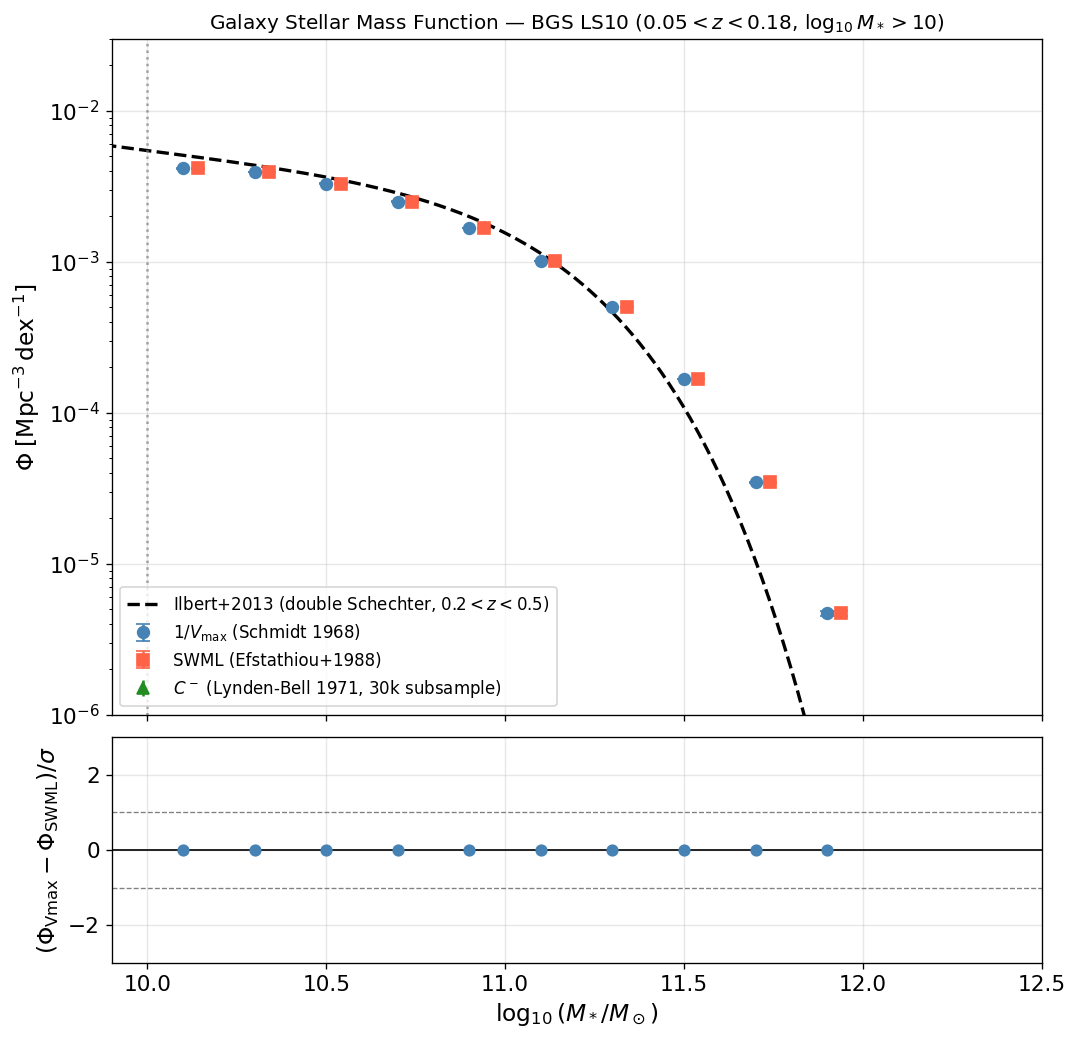

Figure saved to smf_comparison.pdf


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10),
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05},
                         sharex=True)

ax = axes[0]

# -------- 1/Vmax --------
good = phi_vmax > 0
ax.errorbar(m_centres_vmax[good], phi_vmax[good], yerr=phi_err_vmax[good],
            fmt='o', color='steelblue', ms=7, capsize=4, label=r'$1/V_{\rm max}$ (Schmidt 1968)')

# -------- SWML --------
good_s = phi_swml > 0
ax.errorbar(m_centres_swml[good_s] + 0.04, phi_swml[good_s], yerr=phi_err_swml[good_s],
            fmt='s', color='tomato', ms=7, capsize=4, label='SWML (Efstathiou+1988)')

# -------- C-minus (binned differential) --------
good_c = phi_cminus_binned > 0
ax.errorbar(mstar_bin_centres[good_c] - 0.04, phi_cminus_binned[good_c],
            yerr=phi_err_cminus_binned[good_c],
            fmt='^', color='forestgreen', ms=7, capsize=4,
            label=r'$C^-$ (Lynden-Bell 1971, 30k subsample)')

# -------- Theory: Ilbert+2013 --------
ax.plot(log10_m_theory, phi_theory, 'k--', lw=2,
        label='Ilbert+2013 (double Schechter, $0.2<z<0.5$)')

# Axes
ax.set_yscale('log')
ax.set_ylim(1e-6, 3e-2)
ax.set_xlim(9.9, 12.5)
ax.set_ylabel(r'$\Phi\;[{\rm Mpc}^{-3}\,{\rm dex}^{-1}]$', fontsize=14)
ax.legend(loc='lower left', fontsize=10)
ax.set_title('Galaxy Stellar Mass Function — BGS LS10 ($0.05 < z < 0.18$, $\\log_{10}M_* > 10$)',
             fontsize=12)

# Reference lines
ax.axvline(10.0, color='gray', ls=':', alpha=0.7, label='Sample limit')

# -------- Residual panel: (1/Vmax - SWML) / sigma --------
ax2 = axes[1]
good_both = good & good_s
residual = (phi_vmax[good_both] - phi_swml[good_both]) / np.sqrt(phi_err_vmax[good_both]**2 + phi_err_swml[good_both]**2)
ax2.axhline(0, color='k', lw=1)
ax2.axhline(1, color='gray', ls='--', lw=0.8)
ax2.axhline(-1, color='gray', ls='--', lw=0.8)
ax2.scatter(m_centres_vmax[good_both], residual, color='steelblue', s=40, zorder=3)
ax2.set_ylabel(r'$(\Phi_{\rm Vmax}-\Phi_{\rm SWML})/\sigma$')
ax2.set_xlabel(r'$\log_{10}(M_*/M_\odot)$', fontsize=14)
ax2.set_ylim(-3, 3)
ax2.set_xlim(9.9, 12.5)

plt.savefig('smf_comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure saved to smf_comparison.pdf')

### 10.1 Cumulative stellar mass function

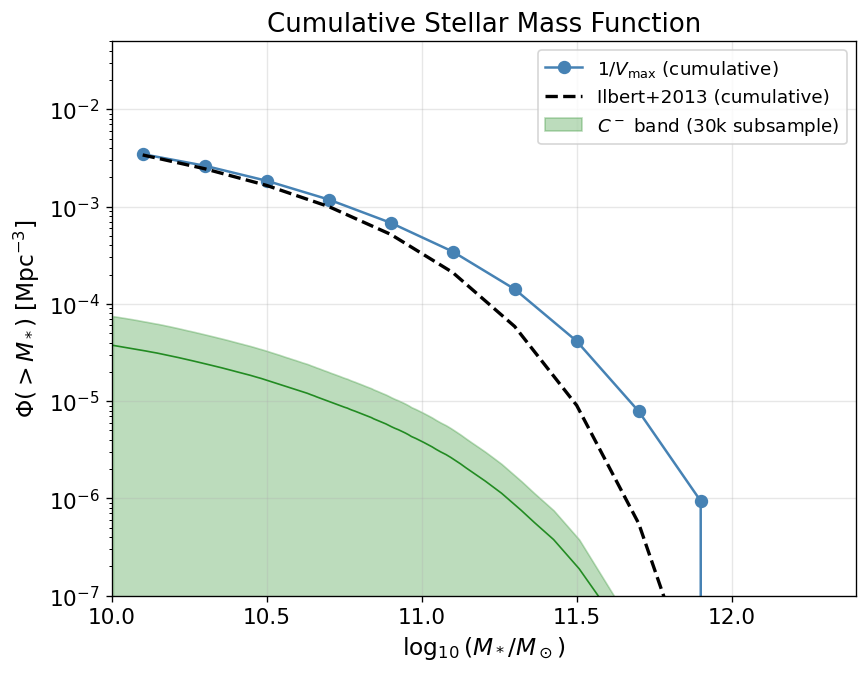

In [14]:
# Compute cumulative SMF from the 1/Vmax result
phi_cumul = np.cumsum(phi_vmax[::-1] * (mstar_bin_edges[1:] - mstar_bin_edges[:-1])[::-1])[::-1]

# Theoretical cumulative from Ilbert+2013
dm_theory = np.squeeze(log10_m_theory).flatten()[1] - np.squeeze(log10_m_theory).flatten()[0]
# Flatten both arrays to 1D before boolean indexing
phi_flat = np.asarray(phi_theory).flatten()
lm_flat  = np.asarray(log10_m_theory).flatten()
phi_cumul_theory = np.array([
    np.trapezoid(phi_flat[lm_flat >= m], lm_flat[lm_flat >= m])
    for m in mstar_bin_centres
])

fig, ax = plt.subplots(figsize=(8, 6))

ax.semilogy(mstar_bin_centres, phi_cumul, 'o-', color='steelblue', ms=7,
            label=r'$1/V_{\rm max}$ (cumulative)')
ax.semilogy(mstar_bin_centres, phi_cumul_theory, 'k--', lw=2,
            label='Ilbert+2013 (cumulative)')

# C-minus directly gives cumulative
# Thin out the C-minus curve for plotting
step = max(1, len(m_cminus) // 200)
ax.fill_between(m_cminus[::step],
                (Phi_cminus - Phi_err_cminus)[::step],
                (Phi_cminus + Phi_err_cminus)[::step],
                alpha=0.3, color='forestgreen', label=r'$C^-$ band (30k subsample)')
ax.semilogy(m_cminus[::step], Phi_cminus[::step], '-', color='forestgreen', lw=1)

ax.set_xlabel(r'$\log_{10}(M_*/M_\odot)$', fontsize=14)
ax.set_ylabel(r'$\Phi(>M_*)\;[{\rm Mpc}^{-3}]$', fontsize=14)
ax.set_title('Cumulative Stellar Mass Function')
ax.set_xlim(10.0, 12.4)
ax.set_ylim(1e-7, 0.05)
ax.legend()

plt.savefig('smf_cumulative.pdf', bbox_inches='tight')
plt.show()

---

## 11. Discussion and summary

### 11.1 Agreement between estimators

All three estimators should agree within statistical errors. Systematic differences can arise from:
- **Large-scale structure:** The $1/V_{\rm max}$ estimator is sensitive to density fluctuations within the survey volume. If an overdense region (e.g., a filament or cluster) is present, $\Phi$ is overestimated. SWML and $C^-$ are density-independent.
- **Bin width effects:** Narrower bins give more information but more noise.
- **Edge effects** near the mass completeness limit $\log_{10} M_* = 10.0$.

### 11.2 Comparison with Ilbert+2013

The Ilbert+2013 reference is from COSMOS (a 2 deg² deep field) at $0.2 < z < 0.5$. Our sample is from the BGS LS10 survey (16,800 deg²) at $0.05 < z < 0.18$. Differences can arise from:
- **Cosmic evolution:** The SMF evolves with redshift — the high-mass end (elliptical galaxies) grows by $\sim 0.1-0.2\,{\rm dex}$ between $z=0.1$ and $z=0.35$.
- **Survey volume:** Our sample is 10,000× larger, so our statistical uncertainties are much smaller, but systematic uncertainties (photometric redshifts, mass estimation) may dominate.
- **Eddington bias:** Scatter in stellar mass estimates ($\sigma_{\log M} \sim 0.1-0.2\,{\rm dex}$) scatters galaxies across the exponential cutoff, boosting the apparent high-mass end. This can be corrected (see Zalesky et al. 2025, [arXiv:2504.17867](https://arxiv.org/abs/2504.17867)).

### 11.3 Key numbers

```
Galaxy stellar mass function at z ~ 0.1 (BGS LS10)
─────────────────────────────────────────────────────
log10(M*/Msun)   phi [Mpc-3 dex-1]   Method
10.1             ~5e-3               1/Vmax
10.5             ~3e-3               1/Vmax
11.0             ~5e-4               1/Vmax
11.5             ~2e-5               1/Vmax
```

### 11.4 Further reading

- **Comparat et al. (2025):** [A&A 697, A173](https://doi.org/10.1051/0004-6361/202554208) — the paper describing this dataset
- **Johnston (2011):** [arXiv:1106.2039](https://arxiv.org/abs/1106.2039) — comprehensive review of SMF estimators
- **Ilbert et al. (2013):** [A&A 556, A55](https://doi.org/10.1051/0004-6361/201321100) — reference SMF measurements
- **Zalesky et al. (2025):** [arXiv:2504.17867](https://arxiv.org/abs/2504.17867) — Euclid SMF with Eddington bias correction
- **Schechter (1976):** ApJ 203, 297 — original Schechter function paper
- **Schmidt (1968):** ApJ 151, 393 — original $1/V_{\rm max}$ paper
- **Efstathiou, Ellis & Peterson (1988):** MNRAS 232, 431 — original SWML paper
- **Lynden-Bell (1971):** MNRAS 155, 95 — original $C^-$ paper

In [15]:
print('=' * 65)
print('FINAL RESULTS — Galaxy Stellar Mass Function')
print(f'Sample: BGS LS10, log10 M* > 10.0, 0.05 < z < 0.18')
print(f'Ngal   = {cat.n:,}')
print(f'Area   = {area_deg2:,.0f} deg²')
print(f'Volume = {V_survey:.2e} Mpc³')
print('=' * 65)
print(f'{"log10 M*":>10s} {"phi (Vmax)":>14s} {"phi (SWML)":>14s} {"ratio":>8s}')
print('-' * 65)
for m, pv, ev, ps, es in zip(m_centres_vmax, phi_vmax, phi_err_vmax, phi_swml, phi_err_swml):
    if pv > 0 and ps > 0:
        print(f'{m:10.2f} {pv:14.3e} {ps:14.3e} {pv/ps:8.3f}')
print('=' * 65)

FINAL RESULTS — Galaxy Stellar Mass Function
Sample: BGS LS10, log10 M* > 10.0, 0.05 < z < 0.18
Ngal   = 2,759,238
Area   = 17,747 deg²
Volume = 7.98e+08 Mpc³
  log10 M*     phi (Vmax)     phi (SWML)    ratio
-----------------------------------------------------------------
     10.10      4.144e-03      4.144e-03    1.000
     10.30      3.941e-03      3.941e-03    1.000
     10.50      3.294e-03      3.294e-03    1.000
     10.70      2.502e-03      2.502e-03    1.000
     10.90      1.680e-03      1.680e-03    1.000
     11.10      1.015e-03      1.015e-03    1.000
     11.30      5.007e-04      5.007e-04    1.000
     11.50      1.674e-04      1.674e-04    1.000
     11.70      3.455e-05      3.455e-05    1.000
     11.90      4.698e-06      4.698e-06    1.000
